# 001 Microstructure

Diego Lozoya Morales | 745345

---

# Libraries

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize

plt.rcParams['figure.facecolor'] = 'lightgrey'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.edgecolor'] = 'black'

colors = ["cornflowerblue", "indianred", "darkseagreen", "plum", "dimgray"]

# Functions

In [2]:
def Erlang(K, lam, S):
     return (lam ** K * S ** (K - 1) * np.exp(-lam * S)) / math.factorial(K - 1)

def PBL(spread):
    p = 0.5 - 0.08 * spread
    return np.maximum(0, p)

def PBS(spread):
    p = 0.5 - 0.08 * spread
    return np.maximum(0, p)

def objective(x, p_i, So, K, lam):
     Ka, Kb = x
     p1 = (1 - p_i) * (PBL(Ka - So) * (Ka - So) + (PBS(So - Kb) * (So - Kb)))
     p2 = quad(lambda S: (S - Ka) * Erlang(K, lam, S), Ka, np.inf)[0]
     p3 = quad(lambda S: (Kb - S) * Erlang(K, lam, S), 0, Kb)[0]
     return -(p1 - p_i * (p2 + p3))

# Price distribution

In [3]:
K = 60
lam = 3
S = np.linspace(10, 33, 1000)

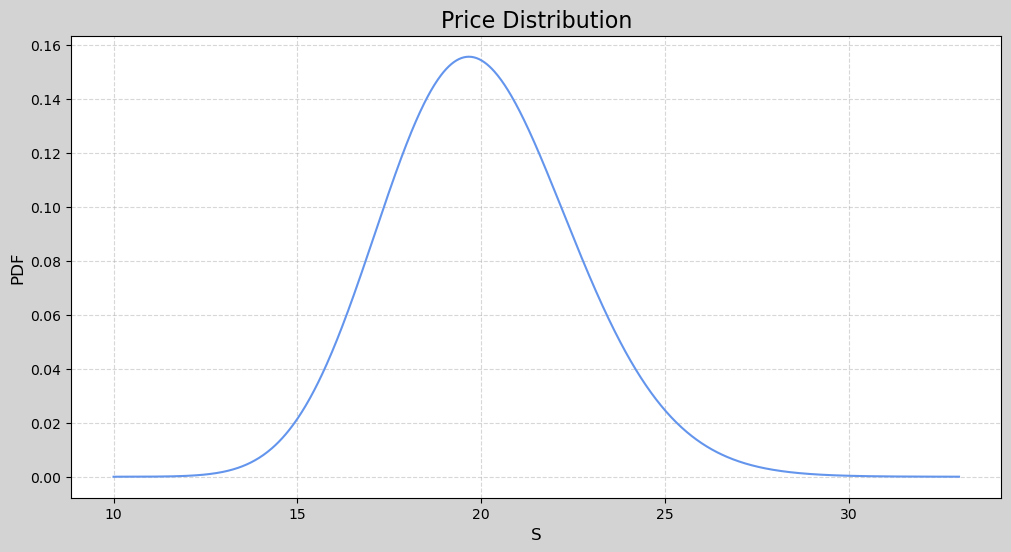

In [4]:
plt.figure()
plt.plot(S, Erlang(K, lam, S), color=colors[0])
plt.title(f'Price Distribution')
plt.xlabel('S')
plt.ylabel('PDF')
plt.show()

# Expected revenue

In [5]:
spread = np.linspace(0, 6, 100)
p_i = 0.4

fun = (1 - p_i) * PBL(spread) * spread

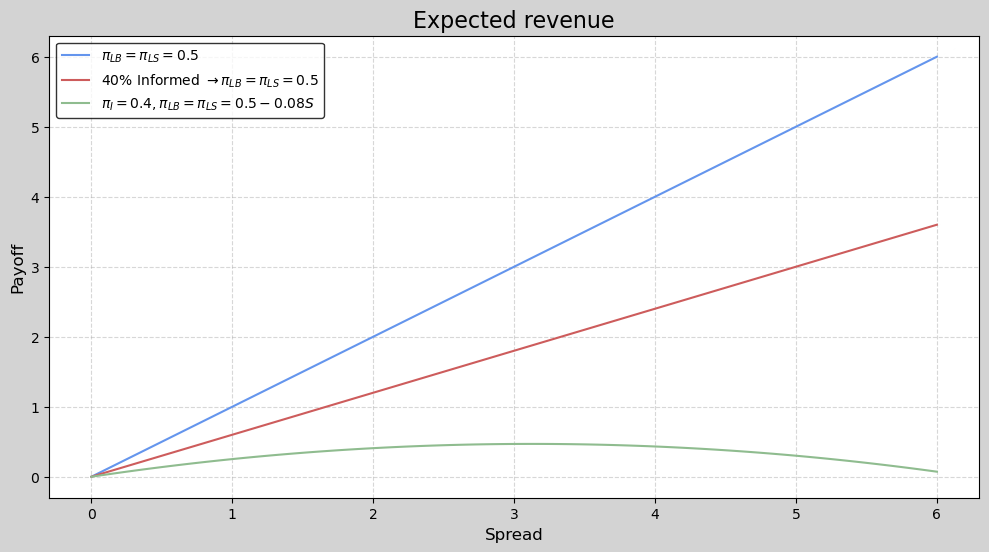

In [6]:
plt.figure()
plt.plot(spread, spread, color=colors[0], label=r'$\pi_{LB} = \pi_{LS} = 0.5$')
plt.plot(spread, (1 - p_i) * spread, color=colors[1], label=r'40% Informed $\rightarrow \pi_{LB} = \pi_{LS} = 0.5$')
plt.plot(spread, fun, color=colors[2], label=r'$\pi_I = 0.4, \pi_{LB} = \pi_{LS} = 0.5 - 0.08S$')
plt.title('Expected revenue')
plt.xlabel('Spread')
plt.ylabel('Payoff')
plt.legend()
plt.show()

# Optimal Bid-Ask

In [7]:
So = 19.9

x0 = [25.0, 15.0]
bounds = [(0, None), (0, None)]
constraint = {'type': 'ineq', 'fun': lambda x: x[0] - x[1]}  

result = minimize(objective, x0, method="SLSQP", args=(p_i, So, K, lam), bounds=bounds, constraints=constraint)
result_x = result.x

print(f'Optimal Ka: {result_x[0]:.2f}\nOptimal Kb: {result_x[1]:.2f}')

Optimal Ka: 23.43
Optimal Kb: 16.45


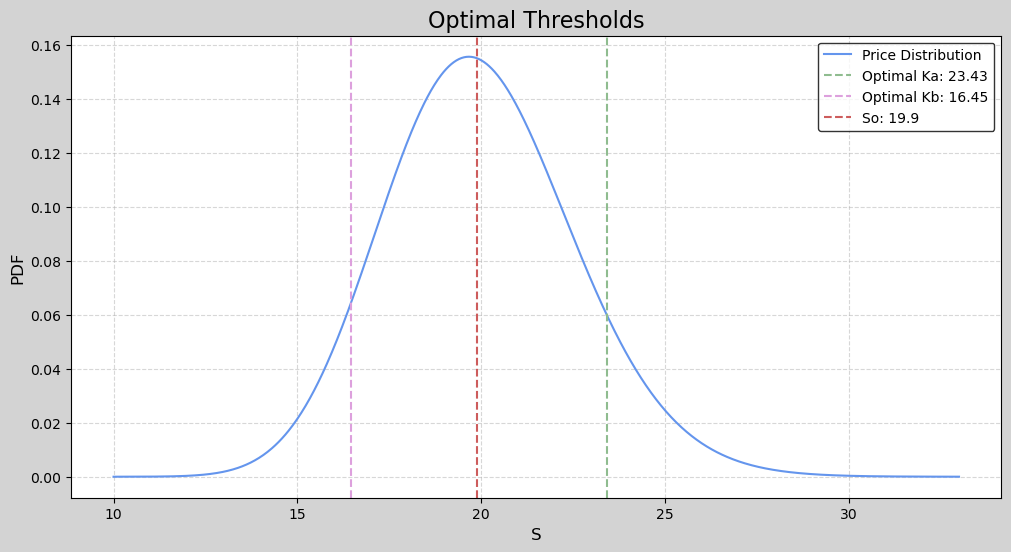

In [ ]:
plt.figure()
plt.plot(S, Erlang(K, lam, S), color=colors[0], label='Price Distribution')
plt.axvline(result_x[0], color=colors[2], linestyle='--', label=f'Optimal Ka: {result_x[0]:.2f}')
plt.axvline(result_x[1], color=colors[3], linestyle='--', label=f'Optimal Kb: {result_x[1]:.2f}')
plt.axvline(So, color=colors[1], linestyle='--', label=f'So: {So}')
plt.title('Optimal Values')
plt.xlabel('S')
plt.ylabel('PDF')
plt.legend()
plt.show()